# EDA -- MS Brain MRI Lesion Segmentation dataset

Dataset: [orvile/multiple-sclerosis-brain-mri-lesion-segmentation](https://www.kaggle.com/datasets/orvile/multiple-sclerosis-brain-mri-lesion-segmentation) (60 MS patients, T1/T2/FLAIR + consensus lesion mask, NIfTI format).

Run `python src/data/download.py` first (requires a configured Kaggle API token -- see the README) so that `data/raw/` is populated before running this notebook.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from src.data.preprocessing import discover_patients, patient_id_from_dir, load_patient_volumes

RAW_DIR = PROJECT_ROOT / "data" / "raw"
patient_dirs = discover_patients(RAW_DIR)
print(f"Found {len(patient_dirs)} patient folders under {RAW_DIR}")
patient_dirs[:5]

Found 60 patient folders under C:\Users\User\Desktop\proyectos_personales\ms-lesion-segmentation\data\raw


[WindowsPath('C:/Users/User/Desktop/proyectos_personales/ms-lesion-segmentation/data/raw/Patient-1'),
 WindowsPath('C:/Users/User/Desktop/proyectos_personales/ms-lesion-segmentation/data/raw/Patient-10'),
 WindowsPath('C:/Users/User/Desktop/proyectos_personales/ms-lesion-segmentation/data/raw/Patient-11'),
 WindowsPath('C:/Users/User/Desktop/proyectos_personales/ms-lesion-segmentation/data/raw/Patient-12'),
 WindowsPath('C:/Users/User/Desktop/proyectos_personales/ms-lesion-segmentation/data/raw/Patient-13')]

## Inspect a single patient's volumes

In [2]:
sample_dir = patient_dirs[0]
sample_id = patient_id_from_dir(sample_dir)
volumes = load_patient_volumes(sample_dir)

for name, vol in volumes.items():
    print(f"{name}: shape={vol.shape}, dtype={vol.dtype}, min={vol.min():.2f}, max={vol.max():.2f}")

t1: shape=(256, 256, 23), dtype=float32, min=0.00, max=1503.71
t2: shape=(256, 256, 23), dtype=float32, min=0.00, max=1634.00
flair: shape=(256, 256, 23), dtype=float32, min=0.00, max=1396.00
mask: shape=(256, 256, 23), dtype=uint8, min=0.00, max=1.00


## Visualize a central axial slice: T1 / T2 / FLAIR + lesion mask overlay

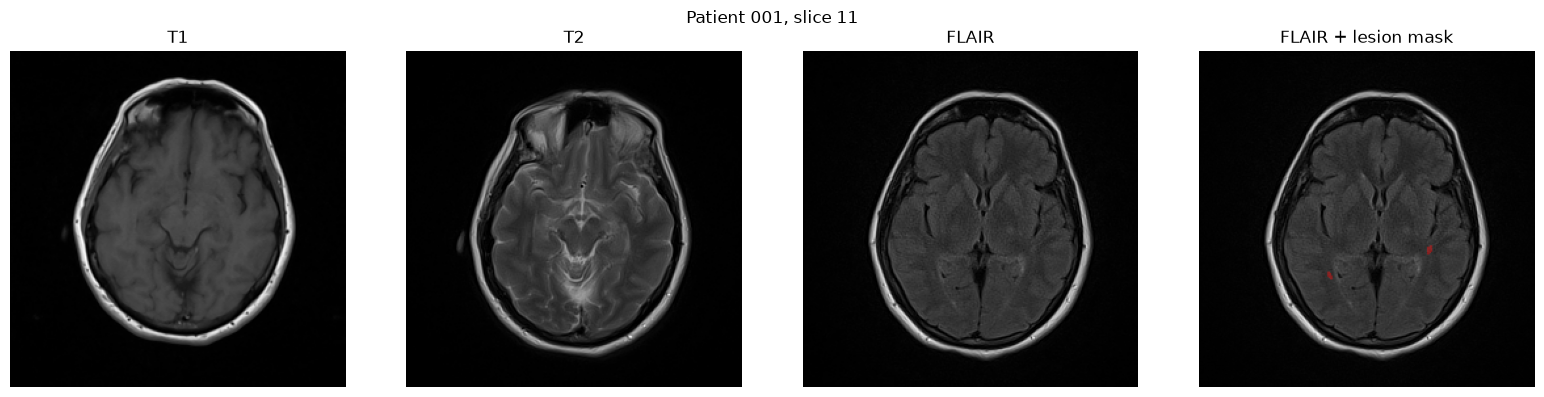

In [3]:
from src.utils.viz import overlay_mask

z = volumes["t1"].shape[2] // 2
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, modality in zip(axes[:3], ["t1", "t2", "flair"]):
    ax.imshow(volumes[modality][:, :, z], cmap="gray")
    ax.set_title(modality.upper())
    ax.axis("off")

overlay_mask(axes[3], volumes["flair"][:, :, z], volumes["mask"][:, :, z])
axes[3].set_title("FLAIR + lesion mask")
fig.suptitle(f"Patient {sample_id}, slice {z}")
fig.tight_layout()

## Lesion load distribution across patients

Medical segmentation datasets are typically very imbalanced (most voxels are healthy tissue/background). This checks per-patient lesion burden and helps decide slice filtering strategy in preprocessing.

In [4]:
records = []
for pdir in patient_dirs:
    pid = patient_id_from_dir(pdir)
    vols = load_patient_volumes(pdir)
    mask = vols["mask"]
    lesion_voxels = int(mask.sum())
    slices_with_lesion = int((mask.sum(axis=(0, 1)) > 0).sum())
    total_slices = mask.shape[2]
    records.append({
        "patient_id": pid,
        "lesion_voxels": lesion_voxels,
        "slices_with_lesion": slices_with_lesion,
        "total_slices": total_slices,
        "pct_slices_with_lesion": 100 * slices_with_lesion / total_slices,
    })

import pandas as pd
lesion_df = pd.DataFrame(records)
lesion_df.describe()

,lesion_voxels,slices_with_lesion,total_slices,pct_slices_with_lesion
count,60.000000,60.000000,60.000000,60.000000
mean,8086.083333,13.116667,24.183333,54.790652
std,12724.711405,3.760146,3.670735,15.142574
min,324.000000,4.000000,18.000000,15.384615
25%,1741.250000,11.000000,21.750000,47.538462
50%,3300.500000,13.000000,25.000000,53.846154
75%,7703.250000,15.000000,26.000000,65.416667
max,60999.000000,22.000000,33.000000,88.888889


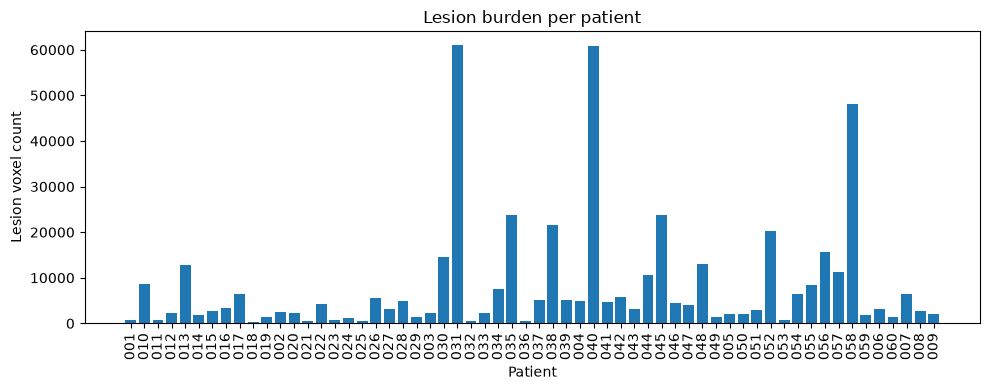

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lesion_df["patient_id"], lesion_df["lesion_voxels"])
ax.set_xlabel("Patient")
ax.set_ylabel("Lesion voxel count")
ax.set_title("Lesion burden per patient")
plt.xticks(rotation=90)
fig.tight_layout()

## Clinical metadata

If the Kaggle download includes a metadata file (EDSS, demographics, etc.), load it here -- the exact filename/format wasn't confirmed before download, so inspect `data/raw/` directly (e.g. `list((PROJECT_ROOT / 'data' / 'raw').glob('*.csv'))` or `*.xlsx`) and adjust the loading code below accordingly.

In [6]:
metadata_candidates = list(RAW_DIR.glob("*.csv")) + list(RAW_DIR.glob("*.xlsx"))
print("Candidate metadata files:", metadata_candidates)

Candidate metadata files: [WindowsPath('C:/Users/User/Desktop/proyectos_personales/ms-lesion-segmentation/data/raw/Supplementary Table 1 for patient info.xlsx'), WindowsPath('C:/Users/User/Desktop/proyectos_personales/ms-lesion-segmentation/data/raw/Supplementary Table 2 for  sequence parameters.xlsx')]
